In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler

# Tính biến x = (Close - Open) / (High - Low), xử lý chia cho 0
data['x'] = data.apply(
    lambda row: (row['Close'] - row['Open']) / (row['High'] - row['Low'])
    if (row['High'] - row['Low']) != 0 else 0,
    axis=1
)

# Hàm chuẩn hóa x về khoảng [0,1]
def normalize_x(x_series):
    min_val = x_series.min()
    max_val = x_series.max()
    range_val = max_val - min_val
    if range_val == 0:
        return x_series * 0  # tránh chia 0
    return (x_series - min_val) / range_val

# Thêm cột x_norm
data['x_norm'] = normalize_x(data['x'])

# GMM xây 5 hàm thuộc
n_mfs = 5
mf_labels = ['so_decrease', 'decrease', 'stable', 'increase', 'so_increase']

x = data['x_norm'].values.reshape(-1, 1)
gmm = GaussianMixture(n_components=n_mfs, random_state=0)
gmm.fit(x)

means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
sorted_idx = np.argsort(means)
sorted_means = means[sorted_idx]
sorted_stds = stds[sorted_idx]

# Hàm Gaussian
def gaussian(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2)

# Tính giá trị hàm thuộc cho toàn bộ data
membership_matrix = np.zeros((len(data), n_mfs))
for i, (mean, std) in enumerate(zip(sorted_means, sorted_stds)):
    membership_matrix[:, i] = gaussian(data['x_norm'].values, mean, std)

# Sinh luật mờ Sugeno bậc nhất
X_input = data[['Open', 'High', 'Low', 'Close']].values
rule_outputs = []
firing_strengths = []

for i in range(n_mfs):
    w = membership_matrix[:, i]
    a = np.random.uniform(-1, 1, size=4)
    b = np.random.uniform(-0.5, 0.5)
    f = X_input @ a + b
    firing_strengths.append(w)
    rule_outputs.append(f)

firing_strengths = np.stack(firing_strengths, axis=1)
rule_outputs = np.stack(rule_outputs, axis=1)

numerator = np.sum(firing_strengths * rule_outputs, axis=1)
denominator = np.sum(firing_strengths, axis=1) + 1e-6  # tránh chia 0
data['y_outputfuzzy'] = numerator / denominator

# ---------------- Vẽ đồ thị ----------------
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))
for i, label in enumerate(mf_labels):
    y = gaussian(x_plot, sorted_means[i], sorted_stds[i])
    plt.plot(x_plot, y, label=label)
plt.title("Membership functions for x_norm")
plt.xlabel("x_norm (normalized (Close - Open)/(High - Low))")
plt.ylabel("Membership Degree")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'data' is not defined

BiLSTM

Kích thước dữ liệu huấn luyện: (4125, 60, 5), (4125, 4)
Kích thước dữ liệu kiểm tra: (1032, 60, 5), (1032, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_9 (Bidirectional) │ (None, 60, 256)        │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 60, 128)        │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,044 (1.31 MB)

 Trainable params: 343,044 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0046 - val_loss: 6.1212e-04
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 7.8708e-04 - val_loss: 0.0026
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5.2662e-04 - val_loss: 2.3969e-04
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 4.5251e-04 - val_loss: 2.6169e-04
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.6410e-04 - val_loss: 2.9858e-04
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 3.1277e-04 - val_loss: 1.3782e-04
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 3.1030e-04 - val_loss: 1.2152e-04
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 2.3668e-04 - val_loss: 8.4723e-05
Epoch 9/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 2.1603e-04 - val_loss: 0.0030
Epoch 10/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 3.8657e-04 - val_loss: 7.2150e-04
Epoch 11/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/s

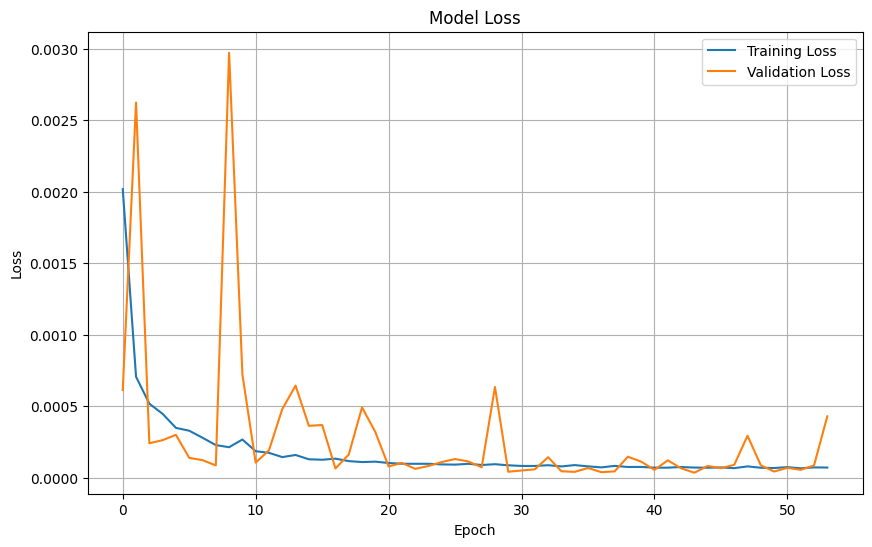

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Low - MSE: 10799.9530, RMSE: 103.9228, MAE: 84.2546, MAPE: 2.9273%, RMSPE: 3.4486%, R2: 0.8950
                     MSE        RMSE        MAE      MAPE     RMSPE        R2
Price Type                                                                   
Close       10388.090371  101.921982  81.215572  2.796587  3.355369  0.900647
Open         9752.661737   98.755566  79.217006  2.722383  3.231674  0.906782
High        10183.011479  100.910909  80.635192  2.756409  3.288717  0.903937
Low         10799.953046  103.922823  84.254598  2.927349  3.448595  0.895014


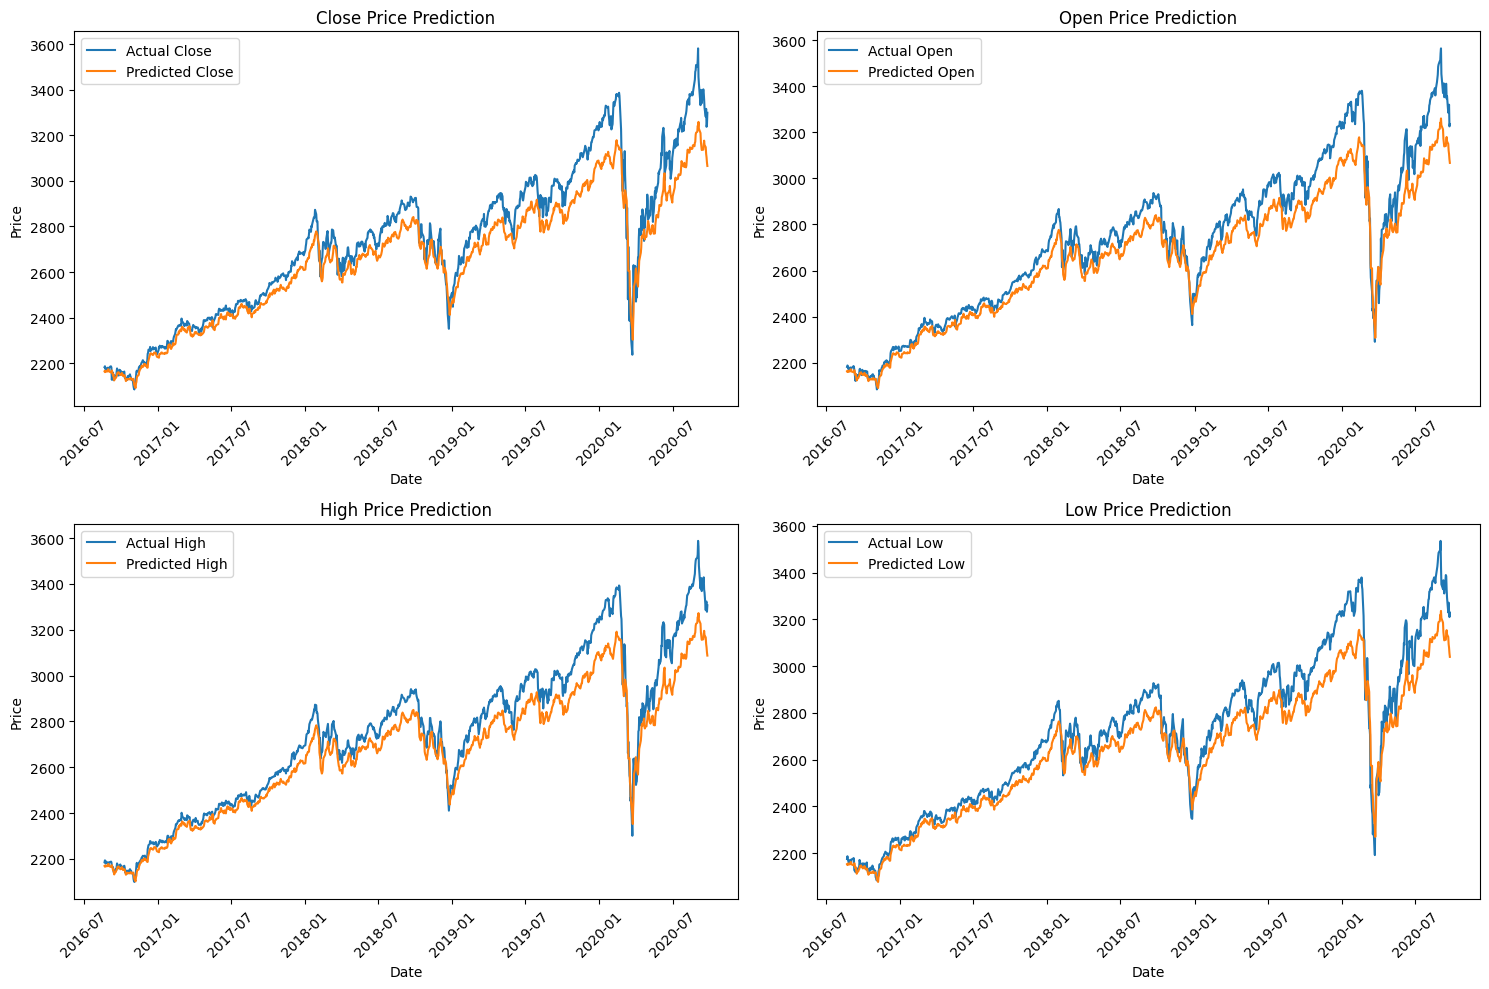

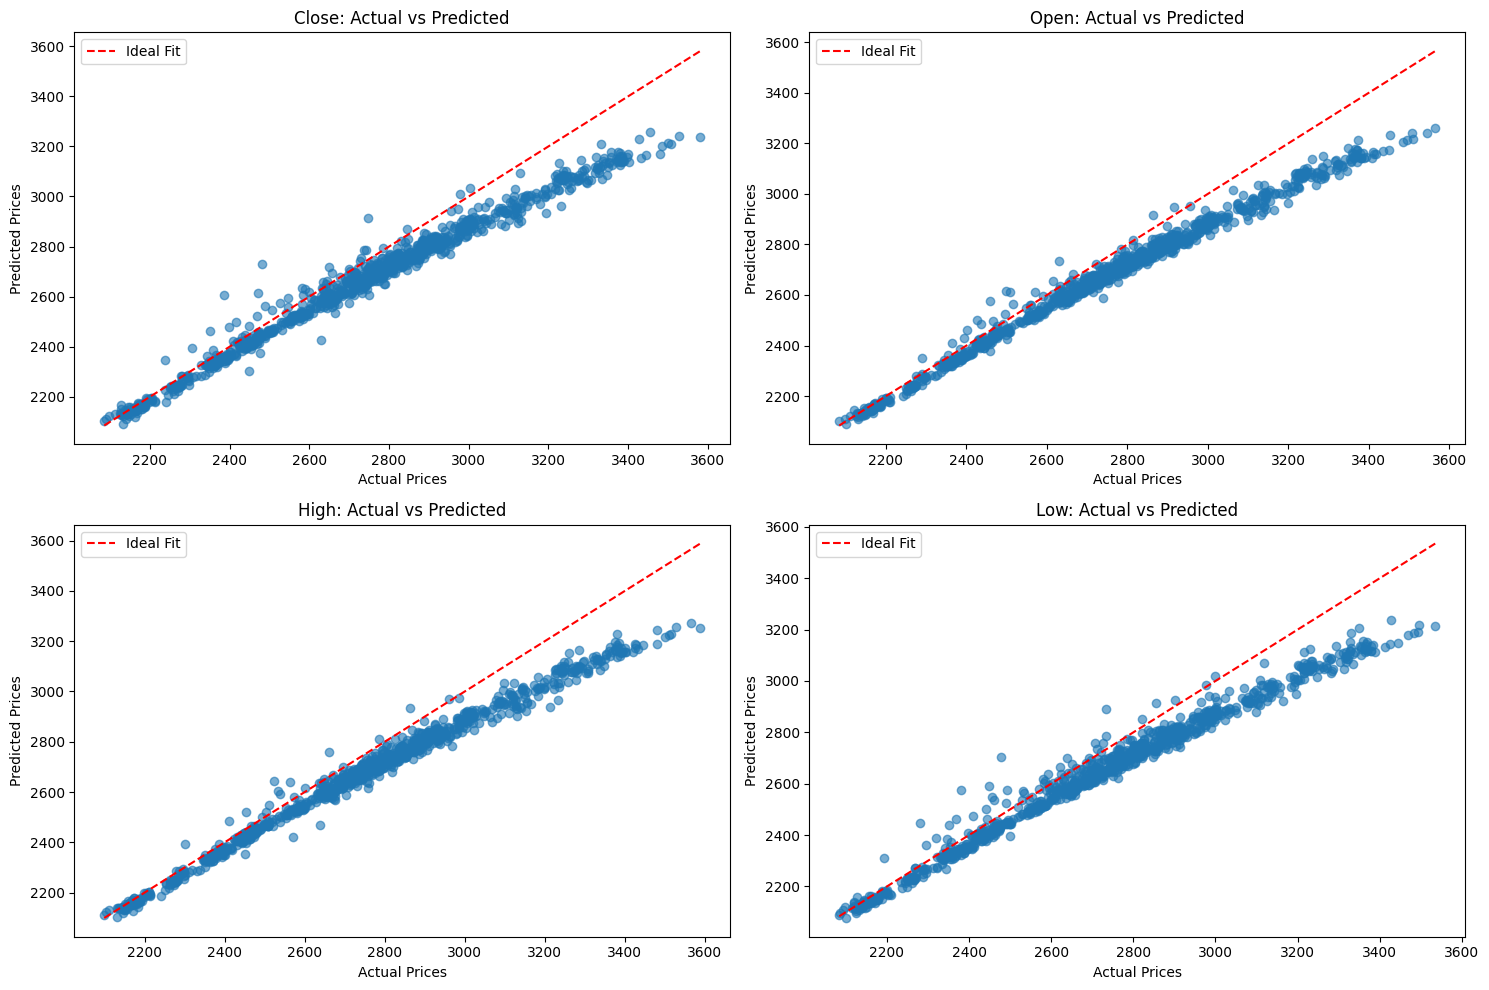

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Dự đoán giá cho 5 ngày tiếp theo:
         Close         Open         High          Low       Date
0  3088.475586  3091.272461  3110.016113  3062.397461 2020-09-26
1  3036.222656  3039.941895  3060.060303  3009.111572 2020-09-27
2  2983.470703  2988.127197  3009.948242  2955.693604 2020-09-28
3  2933.578125  2938.826416  2962.959229  2905.472168 2020-09-29
4  2888.431152  2894.842773  2920.094971  2859.609131 2020-09-30


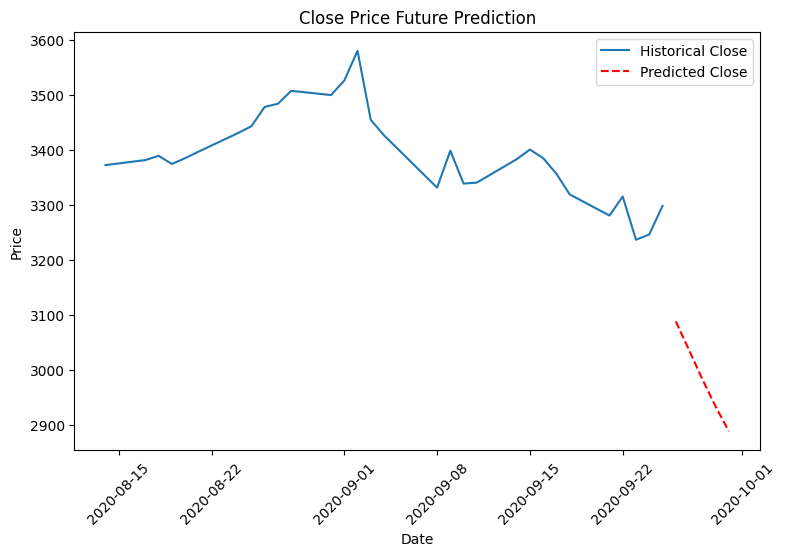

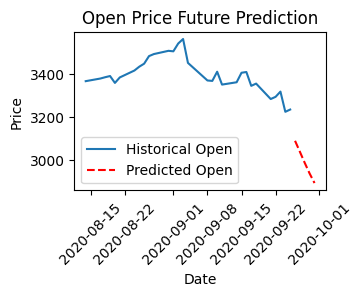

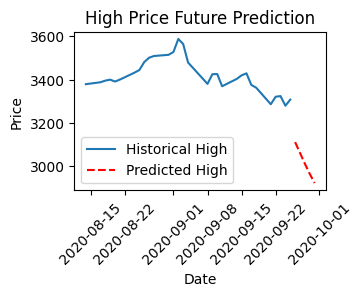

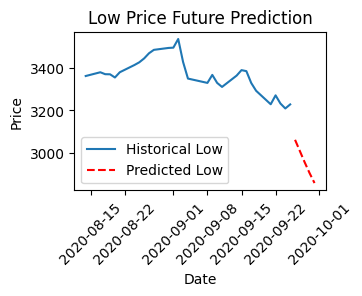

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import math

# Giả sử data đã được tải và có các trường ['Date', 'Close', 'Open', 'High', 'Low', 'y_outputfuzzy']
# Ví dụ:
# data = pd.read_csv('AMZN_original_with_fuzzy.csv')
data['Date'] = pd.to_datetime(data['Date'])

# Chuẩn bị dữ liệu
def prepare_data(data, look_back=60, forecast_horizon=1, train_split=0.8):
    # Chỉ lấy các cột giá
    price_data = data[['Close', 'Open', 'High', 'Low']].values
    fuzzy_data = data[['y_outputfuzzy']].values

    # Chuẩn hóa dữ liệu
    price_scaler = MinMaxScaler(feature_range=(0, 1))
    fuzzy_scaler = MinMaxScaler(feature_range=(0, 1))

    scaled_prices = price_scaler.fit_transform(price_data)
    scaled_fuzzy = fuzzy_scaler.fit_transform(fuzzy_data)

    # Tạo dữ liệu với đầu vào là giá quá khứ và dự đoán fuzzy
    X, y = [], []
    for i in range(len(scaled_prices) - look_back - forecast_horizon + 1):
        # Đặc trưng giá quá khứ
        price_features = scaled_prices[i:(i + look_back)]

        # Đặc trưng fuzzy quá khứ
        fuzzy_features = scaled_fuzzy[i:(i + look_back)]

        # Kết hợp đặc trưng giá và fuzzy
        combined_features = np.column_stack((price_features, fuzzy_features))
        X.append(combined_features)

        # Giá trị cần dự đoán (giá tương lai)
        y.append(scaled_prices[i + look_back + forecast_horizon - 1])

    X, y = np.array(X), np.array(y)

    # Tách tập huấn luyện và tập kiểm tra
    train_size = int(len(X) * train_split)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return X_train, X_test, y_train, y_test, price_scaler

# Xây dựng mô hình BiLSTM
def build_bilstm_model(input_shape, output_dim=4):
    model = Sequential()

    # Layer BiLSTM đầu tiên với return_sequences=True để xếp chồng nhiều layer LSTM
    model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.2))

    # Layer BiLSTM thứ hai
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Dropout(0.2))

    # Layer BiLSTM thứ ba
    model.add(Bidirectional(LSTM(32)))
    model.add(Dropout(0.2))

    # Layer đầu ra với 4 đơn vị cho 4 loại giá
    model.add(Dense(output_dim))

    # Biên dịch mô hình
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return model

# Đánh giá và vẽ biểu đồ kết quả
def evaluate_model(model, X_test, y_test, price_scaler, data, look_back, forecast_horizon):
    # Dự đoán
    y_pred = model.predict(X_test)

    # Inverse transform để có giá thực
    # Tạo mảng có kích thước phù hợp để inverse_transform
    y_test_reshaped = y_test
    y_pred_reshaped = y_pred

    y_test_actual = price_scaler.inverse_transform(y_test_reshaped)
    y_pred_actual = price_scaler.inverse_transform(y_pred_reshaped)

    # Tính metrics cho từng loại giá
    metrics = {}
    price_types = ['Close', 'Open', 'High', 'Low']

    # for i, price_type in enumerate(price_types):
    #     mse = mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i])
    #     rmse = math.sqrt(mse)
    #     mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
    #     r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])

    #     metrics[price_type] = {
    #         'MSE': mse,
    #         'RMSE': rmse,
    #         'MAE': mae,
    #         'R2': r2,
    #     }

    #     print(f"{price_type} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    for i, price_type in enumerate(price_types):
        mse = mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i])
        rmse = math.sqrt(mse)
        mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
        mape = np.mean(np.abs((y_test_actual[:, i] - y_pred_actual[:, i]) / y_test_actual[:, i])) * 100
        rmspe = np.sqrt(np.mean(np.square((y_test_actual[:, i] - y_pred_actual[:, i]) / y_test_actual[:, i]))) * 100
        r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])

        metrics[price_type] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'RMSPE': rmspe,
            'R2': r2,
        }

    print(f"{price_type} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.4f}%, RMSPE: {rmspe:.4f}%, R2: {r2:.4f}")

    metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
    metrics_df.index.name = 'Price Type'
    print(metrics_df)
    # Vẽ biểu đồ dự đoán vs thực tế cho từng loại giá
    test_dates = data['Date'].iloc[len(data) - len(y_test) - forecast_horizon + 1:].values

    plt.figure(figsize=(15, 10))

    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.plot(test_dates, y_test_actual[:, i], label=f'Actual {price_type}')
        plt.plot(test_dates, y_pred_actual[:, i], label=f'Predicted {price_type}')
        plt.title(f'{price_type} Price Prediction')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Vẽ đồ thị với Ox là giá thực và Oy là giá dự đoán
    plt.figure(figsize=(15, 10))

    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.scatter(y_test_actual[:, i], y_pred_actual[:, i], alpha=0.6)
        plt.plot([y_test_actual[:, i].min(), y_test_actual[:, i].max()],
                 [y_test_actual[:, i].min(), y_test_actual[:, i].max()],
                 'r--', label='Ideal Fit')
        plt.title(f'{price_type}: Actual vs Predicted')
        plt.xlabel('Actual Prices')
        plt.ylabel('Predicted Prices')
        plt.legend()

    plt.tight_layout()
    plt.show()

    return metrics, y_test_actual, y_pred_actual

# Chạy toàn bộ quá trình
def run_bilstm_prediction(data, look_back=60, forecast_horizon=1, train_split=0.8, epochs=50, batch_size=32):
    # Chuẩn bị dữ liệu
    X_train, X_test, y_train, y_test, price_scaler = prepare_data(
        data, look_back, forecast_horizon, train_split
    )

    print(f"Kích thước dữ liệu huấn luyện: {X_train.shape}, {y_train.shape}")
    print(f"Kích thước dữ liệu kiểm tra: {X_test.shape}, {y_test.shape}")

    # Xây dựng mô hình
    model = build_bilstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), output_dim=4)
    model.summary()

    # Huấn luyện mô hình với EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Vẽ biểu đồ quá trình huấn luyện
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.savefig('bilstm_training_history.png')
    plt.show()

    # Đánh giá mô hình
    metrics, y_test_actual, y_pred_actual = evaluate_model(
        model, X_test, y_test, price_scaler, data, look_back, forecast_horizon
    )

    # Lưu mô hình
    model.save('bilstm_stock_prediction_model.h5')

    return model, metrics, y_test_actual, y_pred_actual

# Hàm dự đoán giá trong tương lai
def predict_future(model, data, price_scaler, fuzzy_scaler, look_back=60, future_steps=5):
    # Lấy dữ liệu gần nhất để dự đoán
    latest_data = data.iloc[-look_back:].copy()

    latest_prices = latest_data[['Close', 'Open', 'High', 'Low']].values
    latest_fuzzy = latest_data[['y_outputfuzzy']].values

    scaled_prices = price_scaler.transform(latest_prices)
    scaled_fuzzy = fuzzy_scaler.transform(latest_fuzzy)

    combined_data = np.column_stack((scaled_prices, scaled_fuzzy))

    # Dự đoán trong future_steps ngày
    future_predictions = []
    current_input = combined_data.reshape(1, look_back, 5)  # 4 giá + 1 fuzzy

    for _ in range(future_steps):
        # Dự đoán giá tiếp theo
        next_pred = model.predict(current_input)[0]
        future_predictions.append(next_pred)

        # Cập nhật dữ liệu đầu vào cho lần dự đoán tiếp theo
        # Giả định giá trị fuzzy không đổi cho dự đoán tương lai
        next_fuzzy = scaled_fuzzy[-1]

        # Kết hợp giá mới dự đoán với fuzzy giả định
        new_data_point = np.append(next_pred, next_fuzzy)

        # Cập nhật dữ liệu đầu vào bằng cách loại bỏ dòng đầu tiên và thêm dự đoán mới
        current_input = np.roll(current_input, -1, axis=1)
        current_input[0, -1, :] = new_data_point

    # Chuyển đổi dự đoán về giá trị thực
    future_predictions = np.array(future_predictions)
    future_prices = price_scaler.inverse_transform(future_predictions)

    # Tạo DataFrame cho kết quả dự đoán
    last_date = data['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

    price_types = ['Close', 'Open', 'High', 'Low']
    future_df = pd.DataFrame(future_prices, columns=price_types)
    future_df['Date'] = future_dates

    return future_df

# Thực hiện huấn luyện và dự đoán
if __name__ == "__main__":

    # Thiết lập các tham số
    look_back = 60  # Sử dụng 60 ngày dữ liệu quá khứ
    forecast_horizon = 1  # Dự đoán 1 ngày tiếp theo
    train_split = 0.8  # 80% dữ liệu cho huấn luyện
    epochs = 100
    batch_size = 32

    # Huấn luyện mô hình
    model, metrics, y_test_actual, y_pred_actual = run_bilstm_prediction(
        data, look_back, forecast_horizon, train_split, epochs, batch_size
    )

    # Dự đoán giá trong tương lai (5 ngày tiếp theo)
    price_scaler = MinMaxScaler(feature_range=(0, 1))
    price_scaler.fit(data[['Close', 'Open', 'High', 'Low']].values)

    fuzzy_scaler = MinMaxScaler(feature_range=(0, 1))
    fuzzy_scaler.fit(data[['y_outputfuzzy']].values)

    future_predictions = predict_future(model, data, price_scaler, fuzzy_scaler, look_back=look_back, future_steps=5)

    print("\nDự đoán giá cho 5 ngày tiếp theo:")
    print(future_predictions)

    # Vẽ biểu đồ dự đoán tương lai
    plt.figure(figsize=(15, 10))

    # Lấy 30 ngày dữ liệu quá khứ để vẽ xu hướng
    past_days = 30
    past_data = data.iloc[-past_days:].copy()

    price_types = ['Close', 'Open', 'High', 'Low']

    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)

        # Vẽ dữ liệu quá khứ
        plt.plot(past_data['Date'], past_data[price_type], label=f'Historical {price_type}')

        # Vẽ dự đoán tương lai
        plt.plot(future_predictions['Date'], future_predictions[price_type], 'r--', label=f'Predicted {price_type}')

        plt.title(f'{price_type} Price Future Prediction')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.savefig('bilstm_future_predictions.png')
        plt.show()

    # Lưu dự đoán tương lai vào file
    future_predictions.to_csv('AMZN_future_predictions.csv', index=False)

Kích thước dữ liệu huấn luyện: (837, 60, 5), (837, 4)
Kích thước dữ liệu kiểm tra: (359, 60, 5), (359, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 60, 256)        │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 60, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,044 (1.31 MB)

 Trainable params: 343,044 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0227 - val_loss: 0.0014
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0037 - val_loss: 0.0012
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0025 - val_loss: 5.4274e-04
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0018 - val_loss: 6.2921e-04
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0017 - val_loss: 6.2438e-04
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0017 - val_loss: 4.7808e-04
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014 - val_loss: 6.7211e-04
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0016 - val_loss: 3.8505e-04
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0013 - val_loss: 5.7491e-04
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0016 - val_loss: 3.6047e-04
Epoch 12/200
19/19 ━

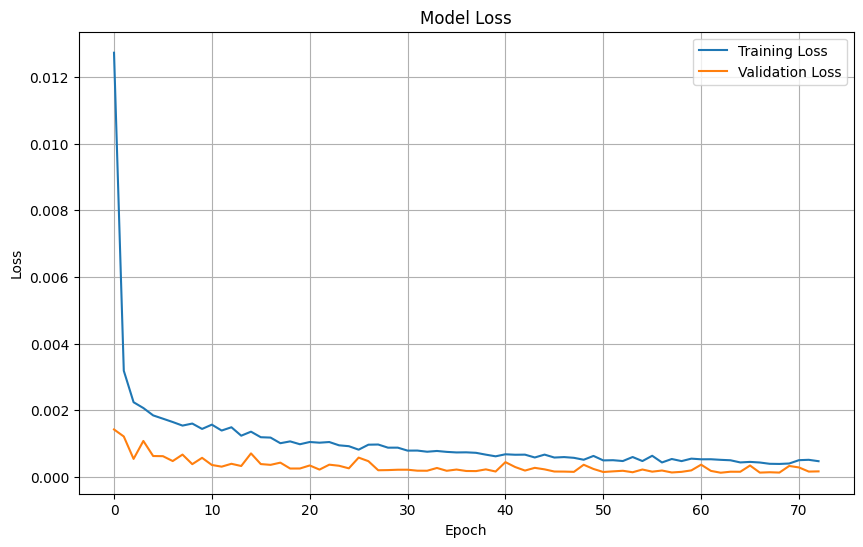

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Low - MSE: 150.8334, RMSE: 12.2814, MAE: 9.8443, MAPE: 4.4888%, RMSPE: 5.2308%, R2: 0.8619
                   MSE       RMSE        MAE      MAPE     RMSPE        R2
Price Type                                                                
Close       179.918138  13.413357  10.563679  4.738010  5.636272  0.839834
Open        121.554456  11.025174   8.658287  3.876490  4.612720  0.893020
High        147.847824  12.159269   9.728607  4.333219  5.087710  0.873191
Low         150.833425  12.281426   9.844339  4.488842  5.230849  0.861938


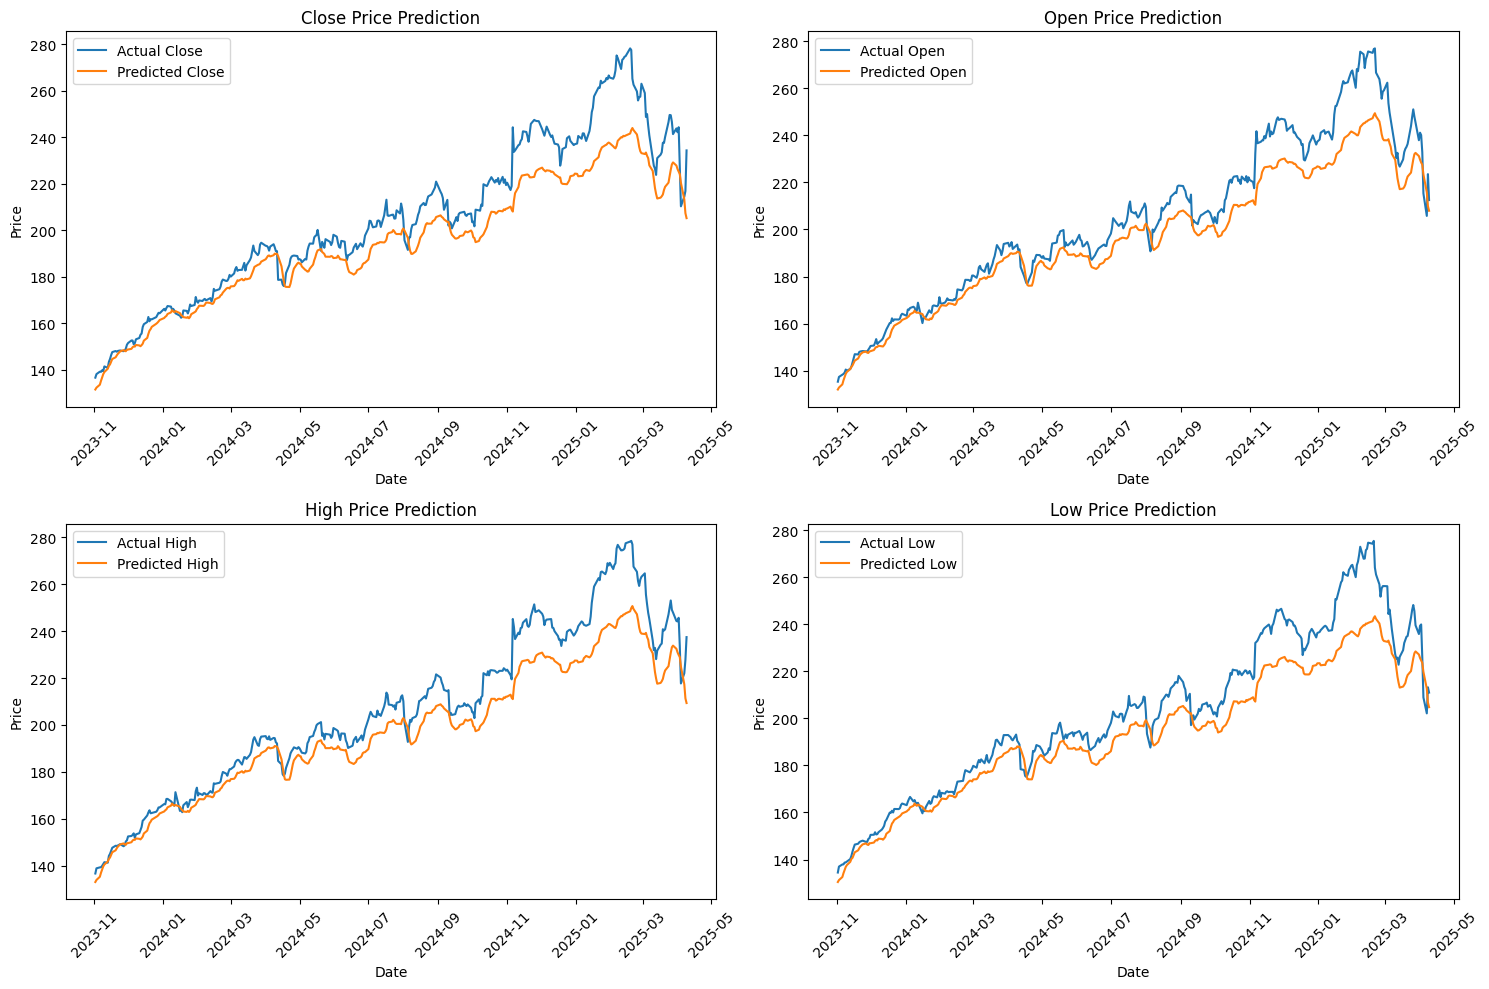

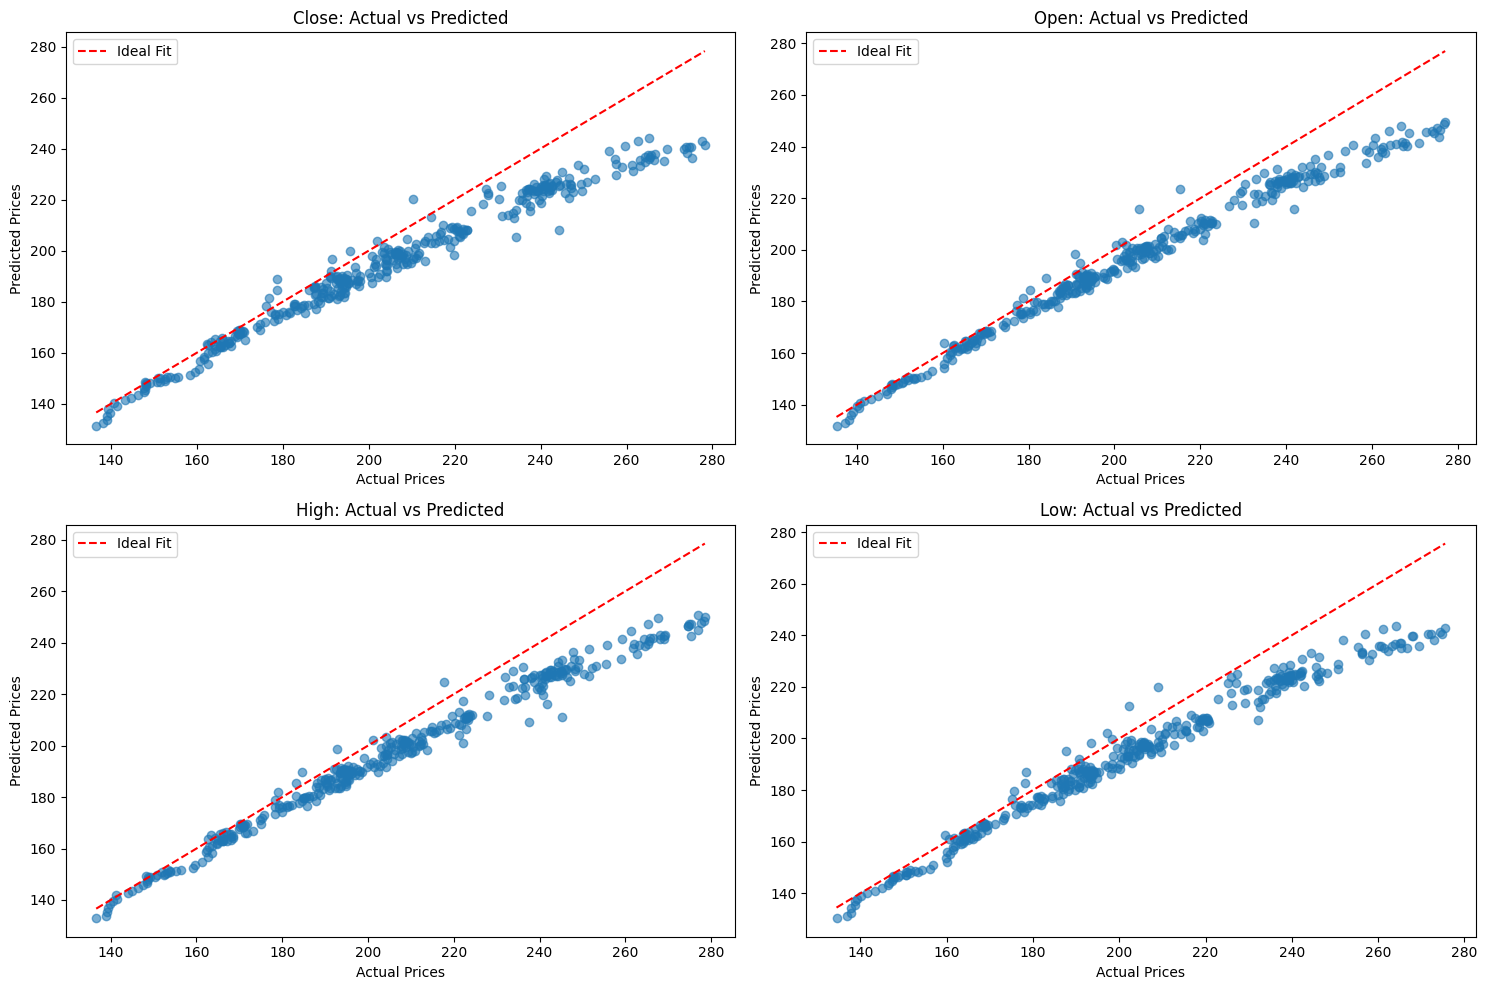

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Dự đoán giá cho 5 ngày tiếp theo:
        Close        Open        High         Low       Date
0  205.969681  209.154068  210.566376  205.846710 2025-04-10
1  202.414169  205.403656  207.006195  202.400238 2025-04-11
2  198.371338  201.278534  203.072586  198.551361 2025-04-12
3  193.875229  196.946686  198.760208  194.202408 2025-04-13
4  189.830856  192.773727  194.734192  190.266083 2025-04-14


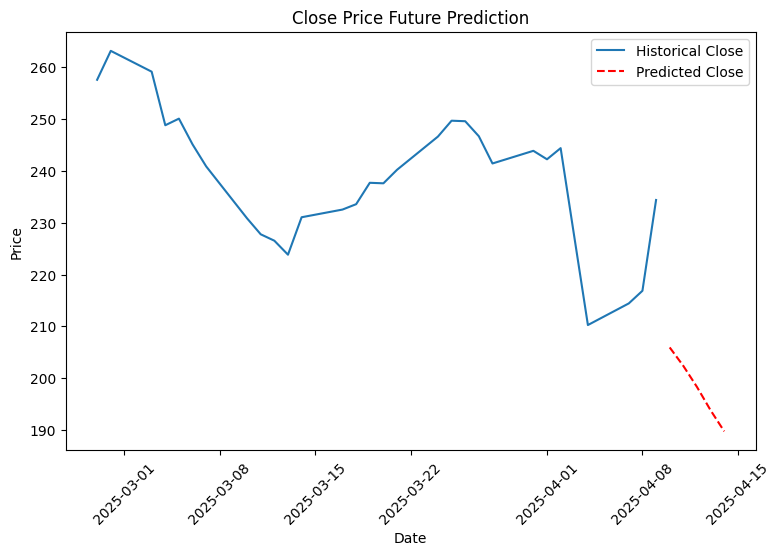

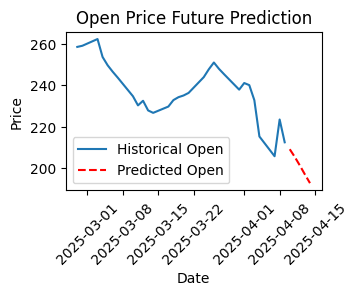

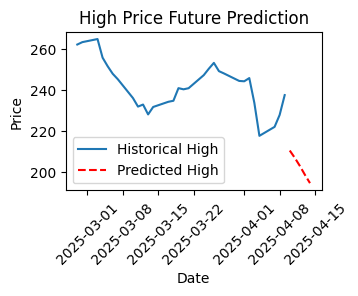

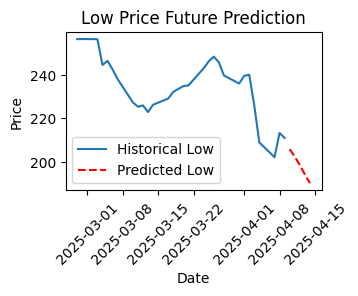

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import math

# Giả sử data đã được tải và có các trường ['Date', 'Close', 'Open', 'High', 'Low', 'y_outputfuzzy']
# Ví dụ:
# data = pd.read_csv('AMZN_original_with_fuzzy.csv')
data['Date'] = pd.to_datetime(data['Date'])

# Chuẩn bị dữ liệu
def prepare_data(data, look_back=60, forecast_horizon=1, train_split=0.8):
    # Chỉ lấy các cột giá
    price_data = data[['Close', 'Open', 'High', 'Low']].values
    fuzzy_data = data[['y_outputfuzzy']].values

    # Chuẩn hóa dữ liệu
    price_scaler = MinMaxScaler(feature_range=(0, 1))
    fuzzy_scaler = MinMaxScaler(feature_range=(0, 1))

    scaled_prices = price_scaler.fit_transform(price_data)
    scaled_fuzzy = fuzzy_scaler.fit_transform(fuzzy_data)

    # Tạo dữ liệu với đầu vào là giá quá khứ và dự đoán fuzzy
    X, y = [], []
    for i in range(len(scaled_prices) - look_back - forecast_horizon + 1):
        # Đặc trưng giá quá khứ
        price_features = scaled_prices[i:(i + look_back)]

        # Đặc trưng fuzzy quá khứ
        fuzzy_features = scaled_fuzzy[i:(i + look_back)]

        # Kết hợp đặc trưng giá và fuzzy
        combined_features = np.column_stack((price_features, fuzzy_features))
        X.append(combined_features)

        # Giá trị cần dự đoán (giá tương lai)
        y.append(scaled_prices[i + look_back + forecast_horizon - 1])

    X, y = np.array(X), np.array(y)

    # Tách tập huấn luyện và tập kiểm tra
    train_size = int(len(X) * train_split)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return X_train, X_test, y_train, y_test, price_scaler

# Xây dựng mô hình BiLSTM
def build_bilstm_model(input_shape, output_dim=4):
    model = Sequential()

    # Layer BiLSTM đầu tiên với return_sequences=True để xếp chồng nhiều layer LSTM
    model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.2))

    # Layer BiLSTM thứ hai
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Dropout(0.2))

    # Layer BiLSTM thứ ba
    model.add(Bidirectional(LSTM(32)))
    model.add(Dropout(0.2))

    # Layer đầu ra với 4 đơn vị cho 4 loại giá
    model.add(Dense(output_dim))

    # Biên dịch mô hình
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return model

# Đánh giá và vẽ biểu đồ kết quả
def evaluate_model(model, X_test, y_test, price_scaler, data, look_back, forecast_horizon):
    # Dự đoán
    y_pred = model.predict(X_test)

    # Inverse transform để có giá thực
    # Tạo mảng có kích thước phù hợp để inverse_transform
    y_test_reshaped = y_test
    y_pred_reshaped = y_pred

    y_test_actual = price_scaler.inverse_transform(y_test_reshaped)
    y_pred_actual = price_scaler.inverse_transform(y_pred_reshaped)

    # Tính metrics cho từng loại giá
    metrics = {}
    price_types = ['Close', 'Open', 'High', 'Low']

    # for i, price_type in enumerate(price_types):
    #     mse = mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i])
    #     rmse = math.sqrt(mse)
    #     mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
    #     r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])

    #     metrics[price_type] = {
    #         'MSE': mse,
    #         'RMSE': rmse,
    #         'MAE': mae,
    #         'R2': r2,
    #     }

    #     print(f"{price_type} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    for i, price_type in enumerate(price_types):
        mse = mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i])
        rmse = math.sqrt(mse)
        mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
        mape = np.mean(np.abs((y_test_actual[:, i] - y_pred_actual[:, i]) / y_test_actual[:, i])) * 100
        rmspe = np.sqrt(np.mean(np.square((y_test_actual[:, i] - y_pred_actual[:, i]) / y_test_actual[:, i]))) * 100
        r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])

        metrics[price_type] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'RMSPE': rmspe,
            'R2': r2,
        }

    print(f"{price_type} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.4f}%, RMSPE: {rmspe:.4f}%, R2: {r2:.4f}")

    metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
    metrics_df.index.name = 'Price Type'
    print(metrics_df)
    # Vẽ biểu đồ dự đoán vs thực tế cho từng loại giá
    test_dates = data['Date'].iloc[len(data) - len(y_test) - forecast_horizon + 1:].values

    plt.figure(figsize=(15, 10))

    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.plot(test_dates, y_test_actual[:, i], label=f'Actual {price_type}')
        plt.plot(test_dates, y_pred_actual[:, i], label=f'Predicted {price_type}')
        plt.title(f'{price_type} Price Prediction')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Vẽ đồ thị với Ox là giá thực và Oy là giá dự đoán
    plt.figure(figsize=(15, 10))

    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.scatter(y_test_actual[:, i], y_pred_actual[:, i], alpha=0.6)
        plt.plot([y_test_actual[:, i].min(), y_test_actual[:, i].max()],
                 [y_test_actual[:, i].min(), y_test_actual[:, i].max()],
                 'r--', label='Ideal Fit')
        plt.title(f'{price_type}: Actual vs Predicted')
        plt.xlabel('Actual Prices')
        plt.ylabel('Predicted Prices')
        plt.legend()

    plt.tight_layout()
    plt.show()

    return metrics, y_test_actual, y_pred_actual

# Chạy toàn bộ quá trình
def run_bilstm_prediction(data, look_back=60, forecast_horizon=1, train_split=0.8, epochs=50, batch_size=32):
    # Chuẩn bị dữ liệu
    X_train, X_test, y_train, y_test, price_scaler = prepare_data(
        data, look_back, forecast_horizon, train_split
    )

    print(f"Kích thước dữ liệu huấn luyện: {X_train.shape}, {y_train.shape}")
    print(f"Kích thước dữ liệu kiểm tra: {X_test.shape}, {y_test.shape}")

    # Xây dựng mô hình
    model = build_bilstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), output_dim=4)
    model.summary()

    # Huấn luyện mô hình với EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.3,
        callbacks=[early_stopping],
        verbose=1
    )

    # Vẽ biểu đồ quá trình huấn luyện
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.savefig('bilstm_training_history.png')
    plt.show()

    # Đánh giá mô hình
    metrics, y_test_actual, y_pred_actual = evaluate_model(
        model, X_test, y_test, price_scaler, data, look_back, forecast_horizon
    )

    # Lưu mô hình
    model.save('bilstm_stock_prediction_model.h5')

    return model, metrics, y_test_actual, y_pred_actual

# Hàm dự đoán giá trong tương lai
def predict_future(model, data, price_scaler, fuzzy_scaler, look_back=60, future_steps=5):
    # Lấy dữ liệu gần nhất để dự đoán
    latest_data = data.iloc[-look_back:].copy()

    latest_prices = latest_data[['Close', 'Open', 'High', 'Low']].values
    latest_fuzzy = latest_data[['y_outputfuzzy']].values

    scaled_prices = price_scaler.transform(latest_prices)
    scaled_fuzzy = fuzzy_scaler.transform(latest_fuzzy)

    combined_data = np.column_stack((scaled_prices, scaled_fuzzy))

    # Dự đoán trong future_steps ngày
    future_predictions = []
    current_input = combined_data.reshape(1, look_back, 5)  # 4 giá + 1 fuzzy

    for _ in range(future_steps):
        # Dự đoán giá tiếp theo
        next_pred = model.predict(current_input)[0]
        future_predictions.append(next_pred)

        # Cập nhật dữ liệu đầu vào cho lần dự đoán tiếp theo
        # Giả định giá trị fuzzy không đổi cho dự đoán tương lai
        next_fuzzy = scaled_fuzzy[-1]

        # Kết hợp giá mới dự đoán với fuzzy giả định
        new_data_point = np.append(next_pred, next_fuzzy)

        # Cập nhật dữ liệu đầu vào bằng cách loại bỏ dòng đầu tiên và thêm dự đoán mới
        current_input = np.roll(current_input, -1, axis=1)
        current_input[0, -1, :] = new_data_point

    # Chuyển đổi dự đoán về giá trị thực
    future_predictions = np.array(future_predictions)
    future_prices = price_scaler.inverse_transform(future_predictions)

    # Tạo DataFrame cho kết quả dự đoán
    last_date = data['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

    price_types = ['Close', 'Open', 'High', 'Low']
    future_df = pd.DataFrame(future_prices, columns=price_types)
    future_df['Date'] = future_dates

    return future_df

# Thực hiện huấn luyện và dự đoán
if __name__ == "__main__":

    # Thiết lập các tham số
    look_back = 60  # Sử dụng 60 ngày dữ liệu quá khứ
    forecast_horizon = 1  # Dự đoán 1 ngày tiếp theo
    train_split = 0.7  # 80% dữ liệu cho huấn luyện
    epochs = 200
    batch_size = 32

    # Huấn luyện mô hình
    model, metrics, y_test_actual, y_pred_actual = run_bilstm_prediction(
        data, look_back, forecast_horizon, train_split, epochs, batch_size
    )

    # Dự đoán giá trong tương lai (5 ngày tiếp theo)
    price_scaler = MinMaxScaler(feature_range=(0, 1))
    price_scaler.fit(data[['Close', 'Open', 'High', 'Low']].values)

    fuzzy_scaler = MinMaxScaler(feature_range=(0, 1))
    fuzzy_scaler.fit(data[['y_outputfuzzy']].values)

    future_predictions = predict_future(model, data, price_scaler, fuzzy_scaler, look_back=look_back, future_steps=5)

    print("\nDự đoán giá cho 5 ngày tiếp theo:")
    print(future_predictions)

    # Vẽ biểu đồ dự đoán tương lai
    plt.figure(figsize=(15, 10))

    # Lấy 30 ngày dữ liệu quá khứ để vẽ xu hướng
    past_days = 30
    past_data = data.iloc[-past_days:].copy()

    price_types = ['Close', 'Open', 'High', 'Low']

    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)

        # Vẽ dữ liệu quá khứ
        plt.plot(past_data['Date'], past_data[price_type], label=f'Historical {price_type}')

        # Vẽ dự đoán tương lai
        plt.plot(future_predictions['Date'], future_predictions[price_type], 'r--', label=f'Predicted {price_type}')

        plt.title(f'{price_type} Price Future Prediction')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.savefig('bilstm_future_predictions.png')
        plt.show()

    # Lưu dự đoán tương lai vào file
    future_predictions.to_csv('AMZN_future_predictions.csv', index=False)

LSTM thay thế

Kích thước dữ liệu huấn luyện: (956, 60, 5), (956, 4)
Kích thước dữ liệu kiểm tra: (240, 60, 5), (240, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,564 (510.02 KB)

 Trainable params: 130,564 (510.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0237 - val_loss: 0.0075
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0042 - val_loss: 0.0059
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0024 - val_loss: 0.0040
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

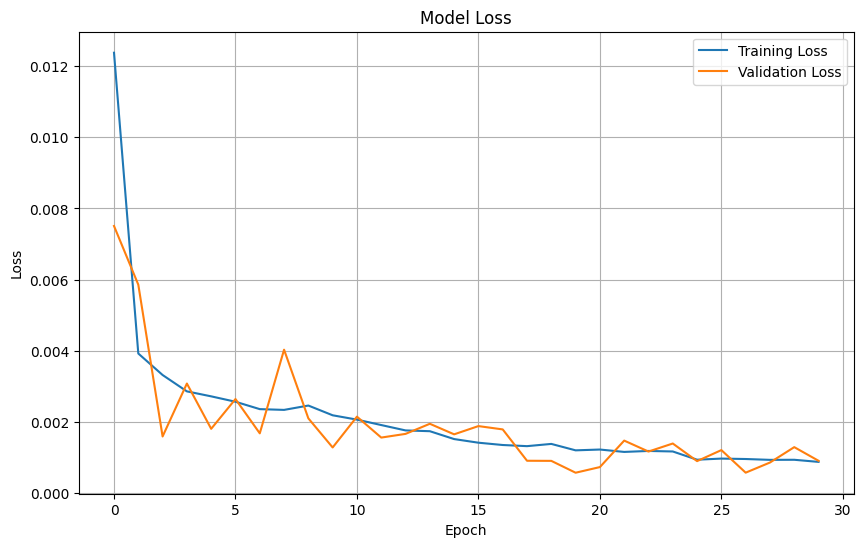

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Close - MSE: 260.1135, RMSE: 16.1280, MAE: 13.3520, MAPE: 5.70%, RMSPE: 6.61%, R2: 0.5643
Open - MSE: 239.2471, RMSE: 15.4676, MAE: 12.6894, MAPE: 5.41%, RMSPE: 6.33%, R2: 0.6027
High - MSE: 264.9837, RMSE: 16.2783, MAE: 13.5497, MAPE: 5.73%, RMSPE: 6.62%, R2: 0.5675
Low - MSE: 212.9252, RMSE: 14.5920, MAE: 11.7183, MAPE: 5.03%, RMSPE: 6.00%, R2: 0.6352


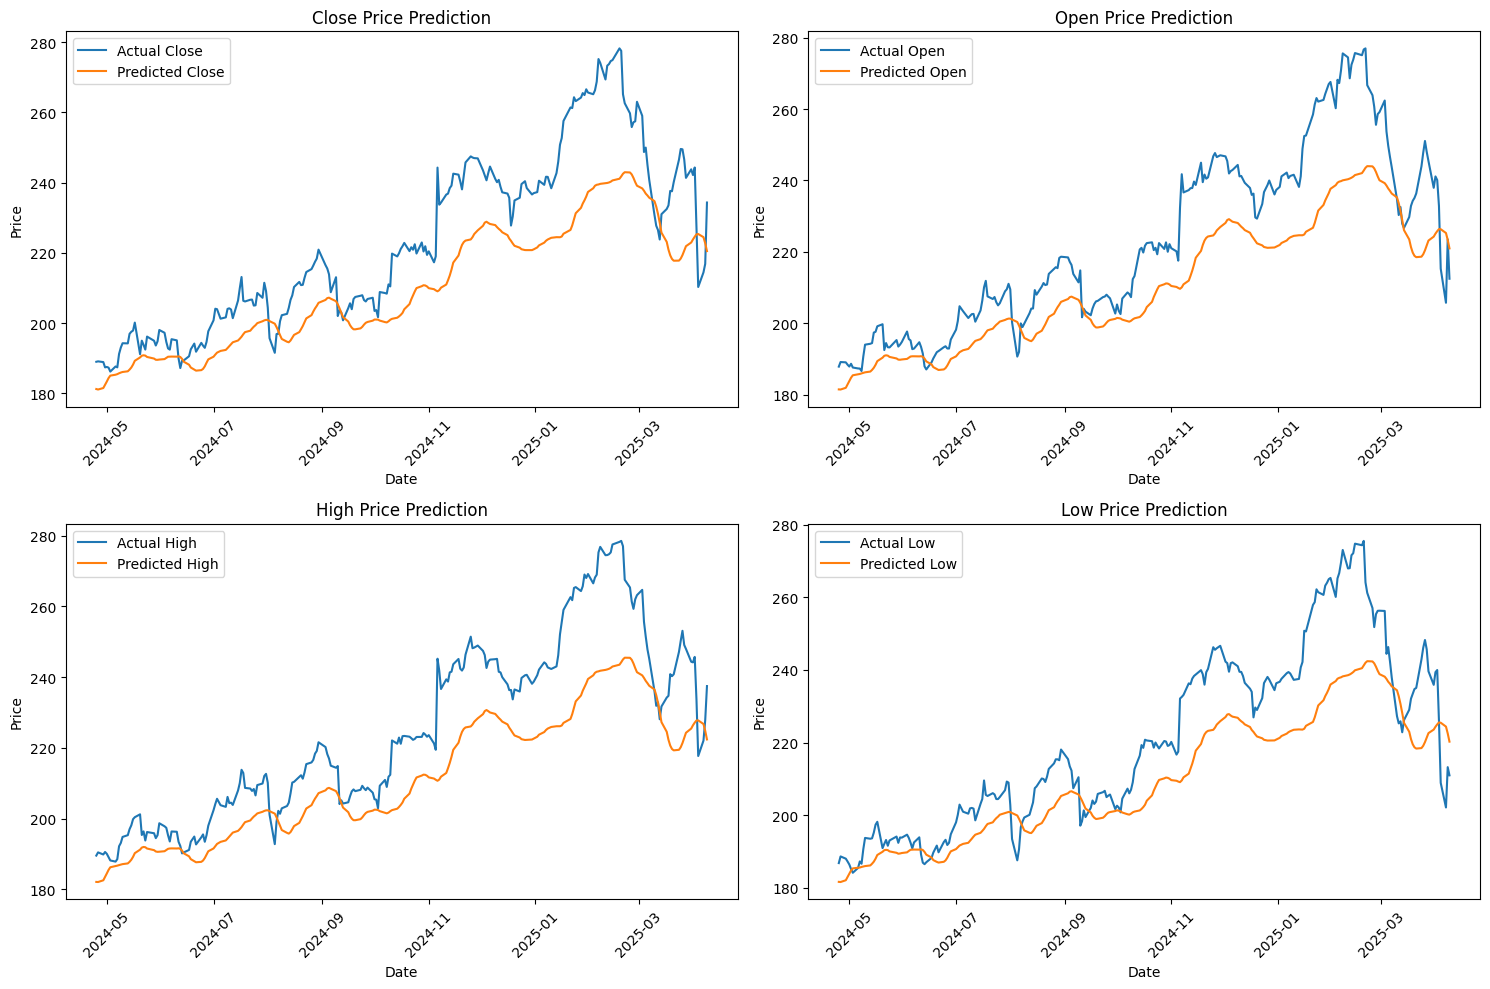

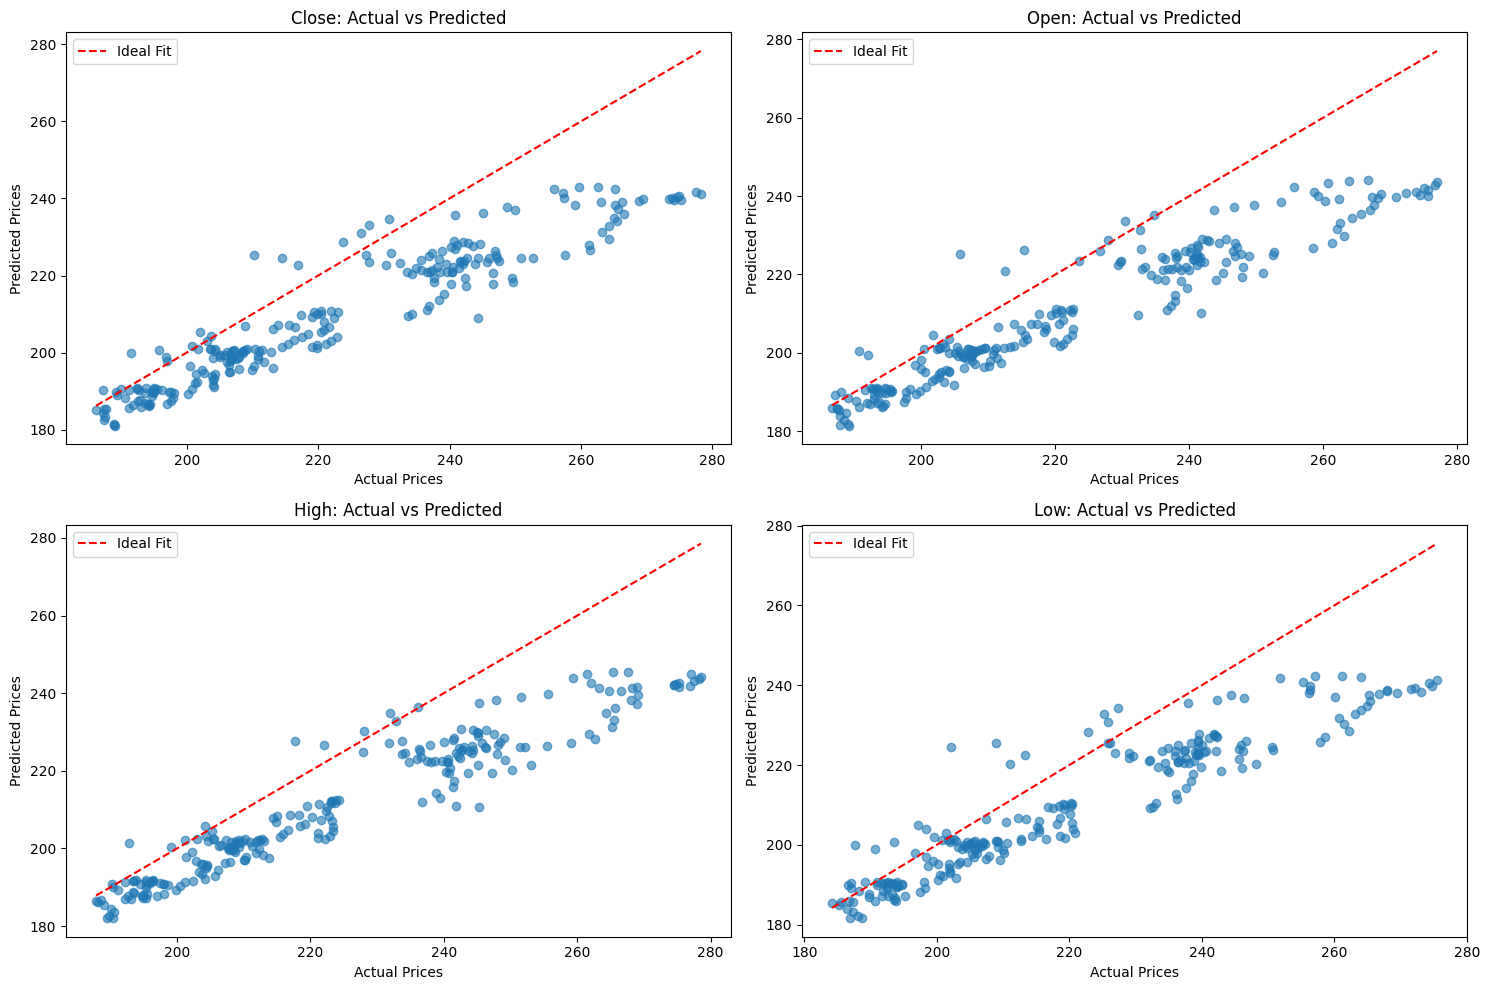

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Dự đoán giá cho 5 ngày tiếp theo:
        Close        Open        High         Low       Date
0  218.340240  218.735367  220.035416  218.167252 2025-04-10
1  216.381165  216.710663  217.906174  216.291733 2025-04-11
2  214.663589  214.958893  216.064590  214.660767 2025-04-12
3  213.171616  213.455460  214.495407  213.242966 2025-04-13
4  211.863983  212.149872  213.148895  211.989777 2025-04-14


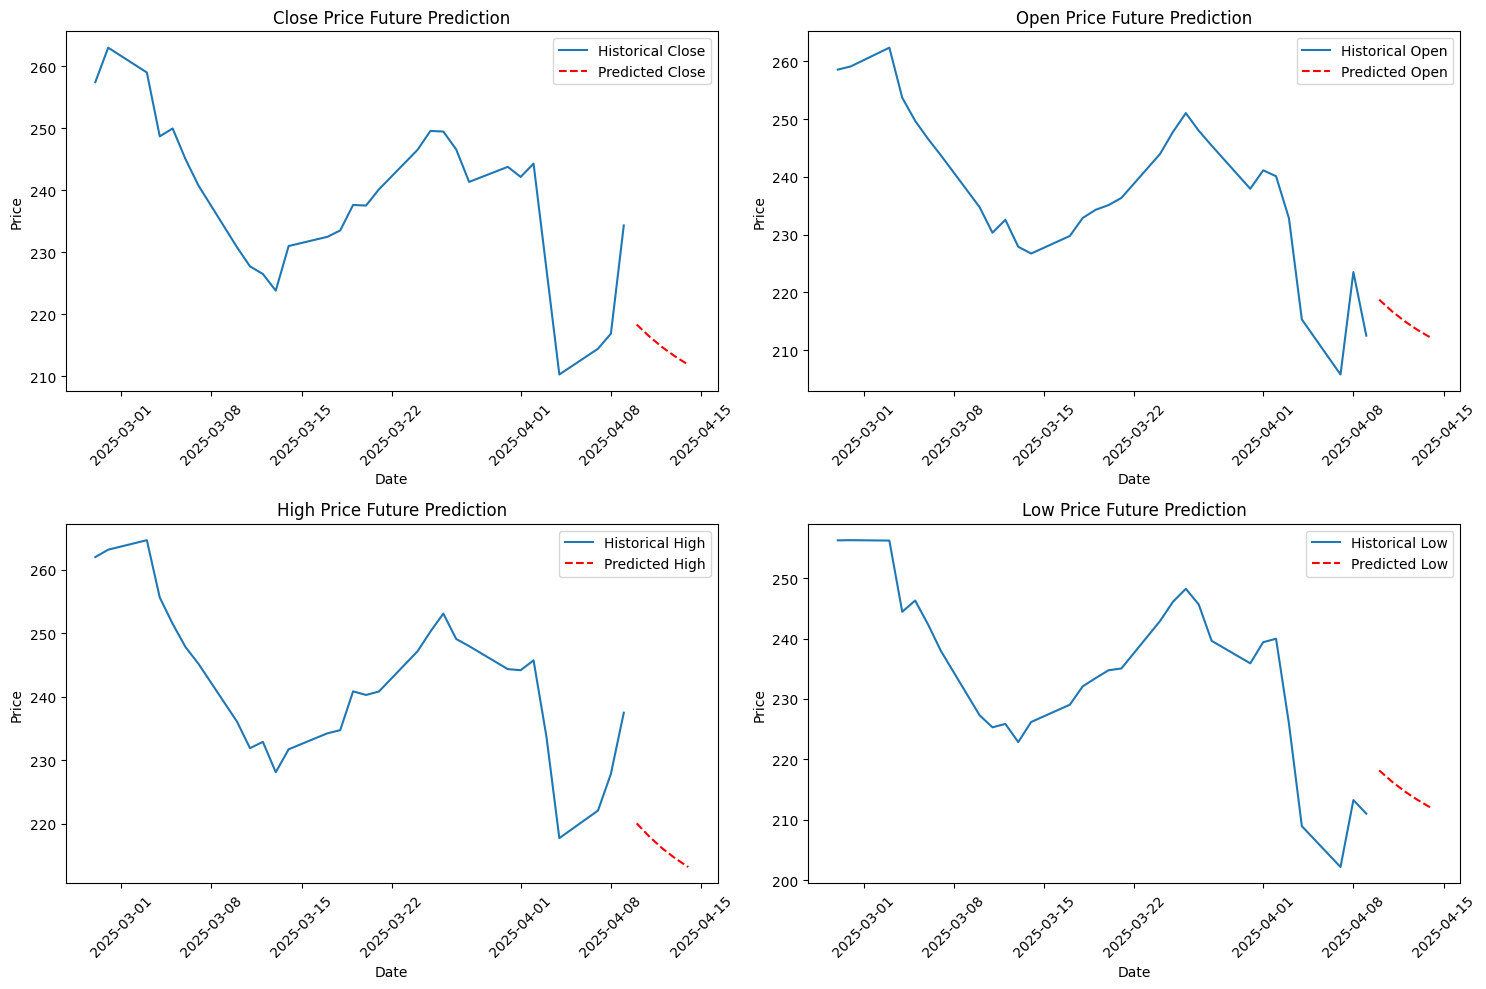

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import math

# Đọc và chuẩn bị dữ liệu
# Giả sử bạn đã load sẵn dữ liệu vào biến `data`
# data = pd.read_csv('AMZN_original_with_fuzzy.csv')
data['Date'] = pd.to_datetime(data['Date'])

def prepare_data(data, look_back=60, forecast_horizon=1, train_split=0.8):
    price_data = data[['Close', 'Open', 'High', 'Low']].values
    fuzzy_data = data[['y_outputfuzzy']].values

    price_scaler = MinMaxScaler(feature_range=(0, 1))
    fuzzy_scaler = MinMaxScaler(feature_range=(0, 1))

    scaled_prices = price_scaler.fit_transform(price_data)
    scaled_fuzzy = fuzzy_scaler.fit_transform(fuzzy_data)

    X, y = [], []
    for i in range(len(scaled_prices) - look_back - forecast_horizon + 1):
        price_features = scaled_prices[i:(i + look_back)]
        fuzzy_features = scaled_fuzzy[i:(i + look_back)]
        combined_features = np.column_stack((price_features, fuzzy_features))
        X.append(combined_features)
        y.append(scaled_prices[i + look_back + forecast_horizon - 1])

    X, y = np.array(X), np.array(y)

    train_size = int(len(X) * train_split)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return X_train, X_test, y_train, y_test, price_scaler
def build_lstm_model(input_shape, output_dim=4):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(output_dim))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model
def evaluate_model(model, X_test, y_test, price_scaler, data, look_back, forecast_horizon):
    y_pred = model.predict(X_test)
    y_test_actual = price_scaler.inverse_transform(y_test)
    y_pred_actual = price_scaler.inverse_transform(y_pred)

    metrics = {}
    price_types = ['Close', 'Open', 'High', 'Low']
    for i, price_type in enumerate(price_types):
        mse = mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i])
        rmse = math.sqrt(mse)
        mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
        mape = np.mean(np.abs((y_test_actual[:, i] - y_pred_actual[:, i]) / y_test_actual[:, i])) * 100
        rmspe = np.sqrt(np.mean(np.square((y_test_actual[:, i] - y_pred_actual[:, i]) / y_test_actual[:, i]))) * 100
        r2 = r2_score(y_test_actual[:, i], y_pred_actual[:, i])
        metrics[price_type] = {
            'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'RMSPE': rmspe, 'R2': r2,
        }
        print(f"{price_type} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%, RMSPE: {rmspe:.2f}%, R2: {r2:.4f}")

    # Vẽ biểu đồ
    test_dates = data['Date'].iloc[len(data) - len(y_test) - forecast_horizon + 1:].values

    plt.figure(figsize=(15, 10))
    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.plot(test_dates, y_test_actual[:, i], label=f'Actual {price_type}')
        plt.plot(test_dates, y_pred_actual[:, i], label=f'Predicted {price_type}')
        plt.title(f'{price_type} Price Prediction')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 10))
    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.scatter(y_test_actual[:, i], y_pred_actual[:, i], alpha=0.6)
        plt.plot([y_test_actual[:, i].min(), y_test_actual[:, i].max()],
                 [y_test_actual[:, i].min(), y_test_actual[:, i].max()], 'r--', label='Ideal Fit')
        plt.title(f'{price_type}: Actual vs Predicted')
        plt.xlabel('Actual Prices')
        plt.ylabel('Predicted Prices')
        plt.legend()
    plt.tight_layout()
    plt.show()

    return metrics, y_test_actual, y_pred_actual
def run_lstm_prediction(data, look_back=60, forecast_horizon=1, train_split=0.8, epochs=50, batch_size=32):
    X_train, X_test, y_train, y_test, price_scaler = prepare_data(
        data, look_back, forecast_horizon, train_split
    )

    print(f"Kích thước dữ liệu huấn luyện: {X_train.shape}, {y_train.shape}")
    print(f"Kích thước dữ liệu kiểm tra: {X_test.shape}, {y_test.shape}")

    model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), output_dim=4)
    model.summary()

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.savefig('lstm_training_history.png')
    plt.show()

    metrics, y_test_actual, y_pred_actual = evaluate_model(
        model, X_test, y_test, price_scaler, data, look_back, forecast_horizon
    )

    model.save('lstm_stock_prediction_model.h5')

    return model, metrics, y_test_actual, y_pred_actual
def predict_future(model, data, price_scaler, fuzzy_scaler, look_back=60, future_steps=5):
    latest_data = data.iloc[-look_back:].copy()
    latest_prices = latest_data[['Close', 'Open', 'High', 'Low']].values
    latest_fuzzy = latest_data[['y_outputfuzzy']].values

    scaled_prices = price_scaler.transform(latest_prices)
    scaled_fuzzy = fuzzy_scaler.transform(latest_fuzzy)
    combined_data = np.column_stack((scaled_prices, scaled_fuzzy))

    future_predictions = []
    current_input = combined_data.reshape(1, look_back, 5)

    for _ in range(future_steps):
        next_pred = model.predict(current_input)[0]
        future_predictions.append(next_pred)
        next_fuzzy = scaled_fuzzy[-1]
        new_data_point = np.append(next_pred, next_fuzzy)
        current_input = np.roll(current_input, -1, axis=1)
        current_input[0, -1, :] = new_data_point

    future_predictions = np.array(future_predictions)
    future_prices = price_scaler.inverse_transform(future_predictions)

    last_date = data['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')
    future_df = pd.DataFrame(future_prices, columns=['Close', 'Open', 'High', 'Low'])
    future_df['Date'] = future_dates

    return future_df
if __name__ == "__main__":
    look_back = 60
    forecast_horizon = 1
    train_split = 0.8
    epochs = 100
    batch_size = 32

    model, metrics, y_test_actual, y_pred_actual = run_lstm_prediction(
        data, look_back, forecast_horizon, train_split, epochs, batch_size
    )

    price_scaler = MinMaxScaler(feature_range=(0, 1))
    price_scaler.fit(data[['Close', 'Open', 'High', 'Low']].values)

    fuzzy_scaler = MinMaxScaler(feature_range=(0, 1))
    fuzzy_scaler.fit(data[['y_outputfuzzy']].values)

    future_predictions = predict_future(model, data, price_scaler, fuzzy_scaler, look_back=look_back, future_steps=5)

    print("\nDự đoán giá cho 5 ngày tiếp theo:")
    print(future_predictions)

    plt.figure(figsize=(15, 10))
    past_days = 30
    past_data = data.iloc[-past_days:].copy()

    price_types = ['Close', 'Open', 'High', 'Low']
    for i, price_type in enumerate(price_types):
        plt.subplot(2, 2, i+1)
        plt.plot(past_data['Date'], past_data[price_type], label=f'Historical {price_type}')
        plt.plot(future_predictions['Date'], future_predictions[price_type], 'r--', label=f'Predicted {price_type}')
        plt.title(f'{price_type} Price Future Prediction')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('lstm_future_predictions.png')
    plt.show()

    future_predictions.to_csv('JPM_future_predictions.csv', index=False)


So sánh 5 Model

In [ ]:
# Required libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten, MaxPooling1D
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


data = data.sort_values('Date').reset_index(drop=True)

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[['Open', 'High', 'Low', 'Close']])
data_scaled = pd.DataFrame(data_scaled, columns=['Open', 'High', 'Low', 'Close'])

# Create sequences
WINDOW = 60

def create_sequences(df, window):
    X, y = [], []
    for i in range(len(df) - window):
        X.append(df.iloc[i:i+window].values)
        y.append(df.iloc[i+window].values)
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, WINDOW)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Flatten for KNN, ANN
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_flat, y_train)
y_pred_knn = knn.predict(X_test_flat)

# ANN (MLP)
ann = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42)
ann.fit(X_train_flat, y_train)
y_pred_ann = ann.predict(X_test_flat)

# EarlyStopping callback
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# LSTM
lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(4)
])
lstm.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')
lstm.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, callbacks=[early_stop])
y_pred_lstm = lstm.predict(X_test)

# RNN
rnn = Sequential([
    SimpleRNN(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(4)
])
rnn.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')
rnn.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, callbacks=[early_stop])
y_pred_rnn = rnn.predict(X_test)

# CNN
cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4)
])
cnn.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')
cnn.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, callbacks=[early_stop])
y_pred_cnn = cnn.predict(X_test)

# Evaluation function
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}\n")

# Evaluate all
evaluate(y_test, y_pred_knn, "KNN")
evaluate(y_test, y_pred_ann, "ANN (MLP)")
evaluate(y_test, y_pred_lstm, "LSTM")
evaluate(y_test, y_pred_rnn, "RNN")
evaluate(y_test, y_pred_cnn, "CNN")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
--- KNN ---
MAE: 0.0866, MSE: 0.0130, RMSE: 0.1139, R2: 0.4401

--- ANN (MLP) ---
MAE: 0.0302, MSE: 0.0015, RMSE: 0.0393, R2: 0.9334

--- LSTM ---
MAE: 0.0121, MSE: 0.0003, RMSE: 0.0162, R2: 0.9886

--- RNN ---
MAE: 0.0119, MSE: 0.0003, RMSE: 0.0158, R2: 0.9892

--- CNN ---
MAE: 0.0143, MSE: 0.0004, RMSE: 0.0190, R2: 0.9844

